<a href="https://colab.research.google.com/github/Alek-2321/Trabalho_Machine_Learning_F.Posser/blob/main/machine_learning_trabalho_F_Posser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Alek-2321/Trabalho_Machine_Learning_F.Posser/blob/main/machine_learning_trabalho_F_Posser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Integração de Dados de Criminalidade e Meteorologia em Passo Fundo

Este projeto foi organizado em etapas para apresentar, de forma clara, o processo de coleta, tratamento, integração e análise dos dados de criminalidade e meteorologia do município de Passo Fundo.

Temos como objetivo analisar a possível influência de variáveis meteorológicas sobre a ocorrência de crimes no município de Passo Fundo. A partir da integração de dados de criminalidade com informações climáticas, busca-se identificar padrões, correlações e possíveis relações entre fatores como temperatura, umidade e precipitação e a variação nos índices criminais ao longo do tempo.


## Etapa 1 — Preparação do ambiente

Nesta etapa são importadas as bibliotecas utilizadas ao longo do projeto. O objetivo é deixar explícitos, desde o início, os recursos necessários para leitura, tratamento, visualização e normalização dos dados.


In [2]:
# Importa as bibliotecas utilizadas no projeto e ajusta algumas opções de exibição do pandas para facilitar a inspeção das tabelas.
import os
import re
import gc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## Etapa 1.2 — Definição dos caminhos dos arquivos

Os caminhos da pasta principal e das subpastas de crimes e clima são configurados nesta etapa. Também são realizados testes simples para confirmar que os diretórios existem antes do início da leitura dos arquivos.


In [3]:
# Monta o Google Drive no ambiente do Colab para permitir o acesso aos arquivos armazenados na pasta do projeto.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Define a pasta principal do trabalho e cria os caminhos das subpastas que armazenam os arquivos de crimes e de clima.

pasta_base = "/content/drive/MyDrive/TRABALHO_MACHINE_LEARNING"
pasta_crimes = os.path.join(pasta_base, "crimes")
pasta_clima = os.path.join(pasta_base, "clima")

In [5]:
# Verifica se os caminhos configurados realmente existem. Essa checagem evita erros de leitura e documenta que a estrutura de pastas foi validada.
print("Pasta base existe?", os.path.exists(pasta_base))
print("Pasta crimes existe?", os.path.exists(pasta_crimes))
print("Pasta clima existe?", os.path.exists(pasta_clima))

Pasta base existe? True
Pasta crimes existe? True
Pasta clima existe? True


## Etapa 1.3 — Busca e organização dos arquivos

Após a definição dos caminhos, os arquivos CSV são localizados e separados por tema:

- dados de criminalidade;
- dados meteorológicos.

Essa verificação é importante para demonstrar que a coleta foi conferida antes do processamento.


In [6]:
# Lista os arquivos CSV disponíveis em cada pasta e separa os conjuntos de dados de criminalidade e meteorologia.
arquivos_crime = sorted([
    os.path.join(pasta_crimes, arquivo)
    for arquivo in os.listdir(pasta_crimes)
    if arquivo.lower().endswith(".csv")
])

arquivos_clima = sorted([
    os.path.join(pasta_clima, arquivo)
    for arquivo in os.listdir(pasta_clima)
    if arquivo.lower().endswith(".csv")
])

print("Arquivos de crimes encontrados:")
for arq in arquivos_crime:
    print("-", arq)

print("\nArquivos de clima encontrados:")
for arq in arquivos_clima:
    print("-", arq)

if not arquivos_crime:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta de crimes.")

if not arquivos_clima:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta de clima.")

Arquivos de crimes encontrados:
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/crimes/SPJ_DADOS_ABERTOS_OCORRENCIAS_JAN_DEZ_2022.csv
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/crimes/SPJ_DADOS_ABERTOS_OCORRENCIAS_JAN_DEZ_2023_em 06.01.2025.csv
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/crimes/SPJ_DADOS_ABERTOS_OCORRENCIAS_JAN_DEZ_2024 - Em 05.01.2026.csv
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/crimes/SPJ_DADOS_ABERTOS_OCORRÊNCIAS_FEV_2026 - Em 05.03.2026.csv
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/crimes/SPJ_DADOS_ABERTOS_OCORRÊNCIAS_JAN_DEZ_2025 - Em 05.01.2026.csv

Arquivos de clima encontrados:
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/clima/PASSO FUNDO - dados_A839_D_2021-01-01_2025-09-05.csv
- /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/clima/dados_A839_D_2025-09-01_2026-04-06.csv


## Etapa 2 — Leitura e concatenação dos dados de criminalidade

Nesta etapa, os arquivos de criminalidade são lidos individualmente e reunidos em um único DataFrame. O procedimento garante a consolidação da base antes do início da limpeza e permite verificar se nenhum arquivo relevante ficou de fora.


In [7]:
# Lê todos os arquivos de criminalidade, padroniza os nomes das colunas, remove colunas totalmente vazias e concatena tudo em uma única base.
def ler_crimes(lista_arquivos):
    # Lista que vai armazenar apenas os recortes necessários de cada arquivo.
    dfs = []

    # Percorre todos os arquivos de crimes encontrados na pasta.
    for caminho in lista_arquivos:
        print(f"Lendo arquivo de crime: {os.path.basename(caminho)}")

        # Lê somente o cabeçalho para identificar, antes da carga completa, quais colunas são úteis.
        colunas_arquivo = pd.read_csv(
            caminho,
            sep=";",
            encoding="latin1",
            nrows=0
        ).columns

        # Padroniza os nomes temporariamente para facilitar a busca por data, município e possíveis identificadores.
        colunas_padronizadas = [col.strip().lower() for col in colunas_arquivo]

        # Identifica a primeira coluna de data disponível no arquivo.
        colunas_data = [col for col in colunas_arquivo if "data" in col.strip().lower()]

        # Identifica a primeira coluna relacionada ao município ou cidade.
        colunas_cidade = [
            col for col in colunas_arquivo
            if "municipio" in col.strip().lower() or "cidade" in col.strip().lower()
        ]

        # Identifica colunas de apoio que podem ajudar na remoção de duplicidades sem carregar a base inteira.
        colunas_id = [
            col for col in colunas_arquivo
            if any(chave in col.strip().lower() for chave in ["id", "ocorr", "fato", "bolet", "protocolo"])
        ]

        # Mantém apenas as colunas realmente necessárias para o tratamento posterior.
        colunas_utilizadas = []
        if colunas_data:
            colunas_utilizadas.append(colunas_data[0])
        if colunas_cidade:
            colunas_utilizadas.append(colunas_cidade[0])
        colunas_utilizadas.extend([col for col in colunas_id if col not in colunas_utilizadas])

        # Se nenhuma coluna essencial for encontrada, o arquivo é ignorado para evitar erro.
        if not colunas_utilizadas:
            print(f"Aviso: nenhuma coluna essencial foi identificada em {os.path.basename(caminho)}")
            continue

        # Lê somente as colunas selecionadas, reduzindo o uso de memória.
        df = pd.read_csv(
            caminho,
            sep=";",
            encoding="latin1",
            low_memory=False,
            usecols=colunas_utilizadas
        )

        # Padroniza os nomes das colunas para manter consistência entre os arquivos.
        df.columns = df.columns.str.strip().str.lower()

        # Remove colunas totalmente vazias no recorte carregado.
        df = df.dropna(axis=1, how="all")

        # Adiciona o DataFrame tratado na lista para concatenação posterior.
        dfs.append(df)

        # Libera referências intermediárias para reduzir pressão de memória.
        del df
        gc.collect()

    # Concatena todos os recortes em uma única base.
    df_crime = pd.concat(dfs, ignore_index=True)

    # Retorna a base consolidada.
    return df_crime


In [66]:
# Lê os arquivos meteorológicos, ignora as linhas iniciais de metadados,
# remove linhas e colunas vazias e consolida os dados em um único DataFrame.
def ler_clima(lista_arquivos):
    # Lista que vai reunir os DataFrames de clima lidos de cada arquivo.
    dfs = []

    # Percorre cada arquivo meteorológico localizado na pasta.
    for caminho in lista_arquivos:
        print(f"Lendo arquivo de clima: {os.path.basename(caminho)}")

        # Lê o arquivo inteiro primeiro para evitar erro na seleção por usecols.
        df = pd.read_csv(
            caminho,
            sep=";",
            encoding="latin1",
            skiprows=9,
            low_memory=False
        )

        # Remove colunas totalmente vazias, caso existam.
        df = df.dropna(axis=1, how="all")

        # Remove linhas completamente vazias.
        df = df.dropna(how="all")

        # Mantém apenas as colunas relevantes pela posição, se existirem.
        colunas_desejadas = [0, 1, 4, 6, 8, 10]
        colunas_validas = [i for i in colunas_desejadas if i < len(df.columns)]
        df = df.iloc[:, colunas_validas]

        # Guarda o resultado para concatenação posterior.
        dfs.append(df)

    # Retorna a base consolidada de clima.
    return pd.concat(dfs, ignore_index=True)

In [77]:
# Executa a leitura das duas coleções de arquivos e apresenta a dimensão inicial das bases de crimes e clima.
# Lê a base consolidada de crimes a partir dos arquivos identificados.
df_crime = ler_crimes(arquivos_crime)

# Lê a base consolidada de clima a partir dos arquivos identificados.
df_clima = ler_clima(arquivos_clima)

# Exibe o tamanho inicial das duas bases para conferência.
print("\nDimensão dos crimes:", df_crime.shape)
print("Dimensão do clima:", df_clima.shape)


Lendo arquivo de crime: SPJ_DADOS_ABERTOS_OCORRENCIAS_JAN_DEZ_2022.csv
Lendo arquivo de crime: SPJ_DADOS_ABERTOS_OCORRENCIAS_JAN_DEZ_2023_em 06.01.2025.csv
Lendo arquivo de crime: SPJ_DADOS_ABERTOS_OCORRENCIAS_JAN_DEZ_2024 - Em 05.01.2026.csv
Lendo arquivo de crime: SPJ_DADOS_ABERTOS_OCORRÊNCIAS_FEV_2026 - Em 05.03.2026.csv
Lendo arquivo de crime: SPJ_DADOS_ABERTOS_OCORRÊNCIAS_JAN_DEZ_2025 - Em 05.01.2026.csv
Lendo arquivo de clima: PASSO FUNDO - dados_A839_D_2021-01-01_2025-09-05.csv
Lendo arquivo de clima: dados_A839_D_2025-09-01_2026-04-06.csv

Dimensão dos crimes: (3052118, 8)
Dimensão do clima: (1927, 3)


## Etapa 3 — Limpeza e padronização dos dados de criminalidade

O tratamento aplicado à base de crimes contempla os seguintes pontos:

- padronização dos nomes das colunas;
- remoção de colunas completamente vazias;
- identificação e conversão da coluna de data;
- filtragem dos registros de Passo Fundo;
- tratamento de ausências em campos essenciais;
- remoção de duplicidades;
- padronização de valores categóricos, quando necessário.

Além da limpeza, esta etapa evidencia uma verificação importante do processo: inicialmente a coluna de data não estava no formato adequado para análise temporal, e por isso foi convertida para `datetime`.


In [78]:
# Aplica a limpeza da base de crimes: padroniza colunas, remove vazios e duplicidades, identifica a coluna de data, converte para datetime e filtra o município de Passo Fundo.
# Padroniza os nomes das colunas para evitar diferenças causadas por espaços e maiúsculas.
df_crime.columns = df_crime.columns.str.strip().str.lower()

# Remove colunas completamente vazias, caso ainda exista alguma após a leitura.
df_crime = df_crime.dropna(axis=1, how="all")

# Identifica quais colunas contêm informação de data.
colunas_data = [col for col in df_crime.columns if "data" in col]
print("Colunas de data encontradas:", colunas_data)

# Define a primeira coluna de data encontrada como referência para o restante do tratamento.
coluna_data_crime = colunas_data[0]

# Identifica a coluna relacionada ao município ou cidade.
colunas_cidade = [col for col in df_crime.columns if "municipio" in col or "cidade" in col]
print("Colunas de cidade encontradas:", colunas_cidade)

# Define, quando existir, a coluna de cidade a ser usada no filtro do município.
coluna_cidade = colunas_cidade[0] if colunas_cidade else None

# Monta dinamicamente um subconjunto de colunas para remoção de duplicidades de forma mais leve.
colunas_para_duplicidade = [coluna_data_crime]
if coluna_cidade:
    colunas_para_duplicidade.append(coluna_cidade)

# Adiciona possíveis colunas de identificação, quando existirem, para refinar a deduplicação.
colunas_id = [
    col for col in df_crime.columns
    if any(chave in col for chave in ["id", "ocorr", "fato", "bolet", "protocolo"])
]
colunas_para_duplicidade.extend([col for col in colunas_id if col not in colunas_para_duplicidade])

# Remove duplicatas com base apenas nas colunas mais relevantes, reduzindo o custo de memória.
df_crime = df_crime.drop_duplicates(subset=colunas_para_duplicidade)

# Converte a coluna de data para o tipo datetime.
df_crime[coluna_data_crime] = pd.to_datetime(df_crime[coluna_data_crime], errors="coerce")

# Remove registros com data inválida, pois eles impedem a agregação correta por dia.
df_crime = df_crime.dropna(subset=[coluna_data_crime])

# Filtra apenas os registros pertencentes ao município de Passo Fundo.
if coluna_cidade:
    df_crime[coluna_cidade] = df_crime[coluna_cidade].astype(str).str.strip().str.upper()
    df_crime = df_crime[df_crime[coluna_cidade] == "PASSO FUNDO"]

# Padroniza colunas categóricas para evitar inconsistências de texto entre arquivos.
colunas_categoricas = df_crime.select_dtypes(include="object").columns

for col in colunas_categoricas:
    df_crime[col] = df_crime[col].astype(str).str.strip().str.lower()

# Exibe a dimensão final da base de crimes após a limpeza.
print("Dimensão final após limpeza:", df_crime.shape)
print(df_crime.info())


Colunas de data encontradas: ['data fato']
Colunas de cidade encontradas: ['municipio fato']
Dimensão final após limpeza: (25474, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 25474 entries, 26 to 3021310
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data fato           25474 non-null  datetime64[ns]
 1   hora fato           25474 non-null  object        
 2   grupo fato          25474 non-null  object        
 3   tipo fato           25474 non-null  object        
 4   municipio fato      25474 non-null  object        
 5   local fato          25474 non-null  object        
 6   quantidade vítimas  25474 non-null  float64       
 7   idade vítima        22270 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 1.7+ MB
None


## Etapa 3.1 — Construção da base diária de criminalidade

Como os registros de ocorrência estão em nível individual e os dados meteorológicos estão organizados por dia, os crimes foram agregados por data. Assim, a base de criminalidade passou a representar a quantidade diária de ocorrências, tornando possível a integração posterior com o clima.


In [79]:
# Agrupa os registros criminais por data e cria a quantidade diária de crimes, preparando a base para a integração com os dados meteorológicos.
# Confere novamente quais colunas de data estão disponíveis na base tratada.
colunas_data = [col for col in df_crime.columns if "data" in col]
print("Colunas de data encontradas:", colunas_data)

# Define a coluna de data usada na agregação diária.
coluna_data_crime = colunas_data[0]

# Agrupa a base de crimes por dia e conta o número de ocorrências em cada data.
df_crime_diario = (
    df_crime
    .groupby(coluna_data_crime)
    .size()
    .reset_index(name="qtd_crimes")
    .rename(columns={coluna_data_crime: "data"})
)

# Libera a base detalhada de crimes após a agregação diária para economizar memória.
del df_crime
gc.collect()

# Exibe a dimensão da base diária já pronta para integração com os dados meteorológicos.
print("Dimensão da base diária de crimes:", df_crime_diario.shape)
print(df_crime_diario.info())
display(df_crime_diario.head())


Colunas de data encontradas: ['data fato']
Dimensão da base diária de crimes: (600, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        600 non-null    datetime64[ns]
 1   qtd_crimes  600 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 9.5 KB
None


,data,qtd_crimes
0,2022-01-01,34
1,2022-01-02,45
2,2022-01-03,45
3,2022-01-04,26
4,2022-01-05,41


## Etapa 4 — Limpeza e padronização do dataset meteorológico

Para a base meteorológica, o tratamento foi direcionado à padronização estrutural e numérica dos dados. Foram realizadas as seguintes ações:

- remoção de colunas e linhas completamente vazias;
- renomeação das colunas para nomes mais objetivos;
- conversão da coluna de data para `datetime`;
- substituição de vírgula por ponto em variáveis numéricas;
- conversão das colunas climáticas para formato numérico;
- remoção de registros com ausências em campos essenciais.

Esse processo garante compatibilidade com a base de criminalidade antes da integração.


In [81]:
# Padroniza a estrutura da base meteorológica, converte a data,
# trata vírgulas decimais, transforma as variáveis climáticas em numéricas
# e remove ausências essenciais.

df_clima = df_clima.rename(columns={
    "Data Medicao": "data",
    "PRECIPITACAO TOTAL, DIARIO (AUT)(mm)": "precipitacao",
    "UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)": "umidade"
})

# Converte a coluna de data
df_clima["data"] = pd.to_datetime(df_clima["data"], errors="coerce")

# Converte colunas numéricas
for col in ["precipitacao", "umidade"]:
    df_clima[col] = df_clima[col].astype(str).str.replace(",", ".", regex=False)
    df_clima[col] = pd.to_numeric(df_clima[col], errors="coerce")

# Remove linhas com valores essenciais ausentes
df_clima = df_clima.dropna(subset=["data", "precipitacao", "umidade"])

# Remove duplicatas
df_clima = df_clima.drop_duplicates()

## Etapa 4.1 — Integração entre criminalidade e meteorologia

A integração foi realizada pela coluna de data, considerando a base de crimes já agregada por dia. O resultado é uma base unificada, contendo a quantidade diária de crimes e as variáveis meteorológicas correspondentes ao mesmo período.


In [82]:
# Realiza o merge entre a base diária de crimes e a base meteorológica utilizando a data como chave de integração.
df_final = pd.merge(df_crime_diario, df_clima, on="data", how="inner")

print("Dimensão da base integrada:", df_final.shape)
display(df_final.head())

Dimensão da base integrada: (525, 4)


,data,qtd_crimes,precipitacao,umidade
0,2022-01-01,34,0.0,48.6
1,2022-01-02,45,0.0,52.3
2,2022-01-03,45,4.6,78.0
3,2022-01-04,26,4.4,85.9
4,2022-01-05,41,10.6,89.0


## Etapa 5 — Consolidação da base analítica por dia

Depois do merge, a base integrada passa por verificações finais de consistência, com foco em:

- remoção de duplicidades;
- eliminação de colunas totalmente vazias, se existirem;
- conferência de valores ausentes;
- manutenção apenas de registros com informações essenciais.

Essa etapa gera a base analítica final utilizada nas análises exploratórias.


In [31]:
# Faz as verificações finais da base integrada, removendo duplicidades, colunas totalmente vazias e linhas com ausência em variáveis essenciais.
# Remove registros duplicados da base integrada.
df_final = df_final.drop_duplicates(subset=["data", "qtd_crimes", "precipitacao", "umidade"])

# Remove colunas completamente vazias, se houver.
df_final = df_final.dropna(axis=1, how="all")

# Verifica a quantidade de valores ausentes em cada coluna.
print("Valores ausentes por coluna:")
print(df_final.isna().sum())

# Define as colunas essenciais que precisam estar preenchidas para a base final permanecer consistente.
colunas_essenciais = ["data", "qtd_crimes", "precipitacao", "umidade"]

# Remove linhas com ausências nas variáveis consideradas essenciais para a análise.
df_final = df_final.dropna(subset=colunas_essenciais)

# Exibe a dimensão final da base integrada após os ajustes.
print("\nDimensão final após limpeza:", df_final.shape)
display(df_final.head())


Valores ausentes por coluna:
data            0
qtd_crimes      0
precipitacao    0
umidade         0
dtype: int64

Dimensão final após limpeza: (525, 4)


,data,qtd_crimes,precipitacao,umidade
0,2022-01-01,34,0.0,48.6
1,2022-01-02,45,0.0,52.3
2,2022-01-03,45,4.6,78.0
3,2022-01-04,26,4.4,85.9
4,2022-01-05,41,10.6,89.0


A compatibilização entre as bases exigiu a agregação dos crimes por data, pois os dados meteorológicos já estavam em granularidade diária. Após a integração, foram aplicadas verificações adicionais para garantir consistência, removendo duplicidades e ausências em campos essenciais da base final.


## Etapa 5.1 — Identificação de colunas vazias e análise de outliers

Nesta etapa, a atenção se volta à qualidade estatística da base final. Primeiro, garante-se que não existam colunas integralmente vazias. Em seguida, a variável `qtd_crimes` é analisada com o método do intervalo interquartil (IQR), permitindo identificar dias com comportamento muito distante do padrão observado.


In [32]:
# Calcula os limites do método IQR para identificar dias com quantidade de crimes muito acima ou abaixo do comportamento típico da série.
# Calcula o primeiro quartil da variável quantidade de crimes.
Q1 = df_final["qtd_crimes"].quantile(0.25)

# Calcula o terceiro quartil da variável quantidade de crimes.
Q3 = df_final["qtd_crimes"].quantile(0.75)

# Calcula o intervalo interquartil.
IQR = Q3 - Q1

# Define o limite inferior para identificação de outliers.
limite_inferior = Q1 - 1.5 * IQR

# Define o limite superior para identificação de outliers.
limite_superior = Q3 + 1.5 * IQR

# Seleciona os registros que ficaram abaixo do limite inferior ou acima do limite superior.
outliers = df_final[
    (df_final["qtd_crimes"] < limite_inferior) |
    (df_final["qtd_crimes"] > limite_superior)
]

# Exibe os valores de referência calculados para a análise de outliers.
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)
print("Quantidade de outliers encontrados:", outliers.shape[0])

# Mostra uma amostra dos registros classificados como outliers.
display(outliers.head())


Q1: 36.0
Q3: 49.0
IQR: 13.0
Limite inferior: 16.5
Limite superior: 68.5
Quantidade de outliers encontrados: 0


,data,qtd_crimes,precipitacao,umidade


Os outliers da variável `qtd_crimes` foram identificados com base no método do intervalo interquartil (IQR). O objetivo não foi eliminar automaticamente esses registros, mas destacar dias atípicos para avaliação. Em dados de segurança pública, valores extremos podem representar eventos reais e relevantes, e não necessariamente erros de entrada.


In [33]:
# Cria uma cópia da base final para análise, preservando os registros identificados como outliers.
# Cria a base que será usada nas análises e visualizações posteriores.
df_analise = df_final.copy()

# Exibe a dimensão da base mantida para análise.
print("Dimensão da base mantida para análise:", df_analise.shape)


Dimensão da base mantida para análise: (525, 4)


Os registros classificados como outliers foram mantidos na base analítica. Essa decisão foi adotada porque valores extremos, neste contexto, podem refletir a dinâmica real da criminalidade e contribuir para a interpretação dos resultados.


## Etapa 5.2 — Normalização das variáveis numéricas

Com a base já tratada, as variáveis numéricas de interesse foram normalizadas por meio do método Min-Max. A padronização da escala favorece comparações entre variáveis e apoia análises posteriores.


In [35]:
# Aplica a normalização Min-Max nas variáveis numéricas selecionadas e gera a base preparada para comparações em mesma escala.
# Cria uma cópia da base analítica para preservar os dados originais antes da normalização.
df_modelo = df_analise.copy()

# Define as colunas numéricas que serão normalizadas.
colunas_numericas = ["qtd_crimes", "precipitacao", "umidade"]

# Instancia o normalizador Min-Max.
scaler = MinMaxScaler()

# Aplica a normalização nas variáveis numéricas selecionadas.
df_modelo[colunas_numericas] = scaler.fit_transform(df_modelo[colunas_numericas])

# Exibe as primeiras linhas da base normalizada.
display(df_modelo.head())


,data,qtd_crimes,precipitacao,umidade
0,2022-01-01,0.319149,0.000000,0.165232
1,2022-01-02,0.553191,0.000000,0.228916
2,2022-01-03,0.553191,0.029948,0.671256
3,2022-01-04,0.148936,0.028646,0.807229
4,2022-01-05,0.468085,0.069010,0.860585


As variáveis numéricas foram normalizadas para o intervalo entre 0 e 1. Esse procedimento não altera a relação entre os dados, mas facilita a comparação entre medidas que originalmente estavam em escalas diferentes.


## Etapa 6 — Exploração inicial dos dados

Nesta etapa são apresentados gráficos e medidas exploratórias que ajudam a observar padrões, dispersões e possíveis relações entre a criminalidade e as condições meteorológicas.


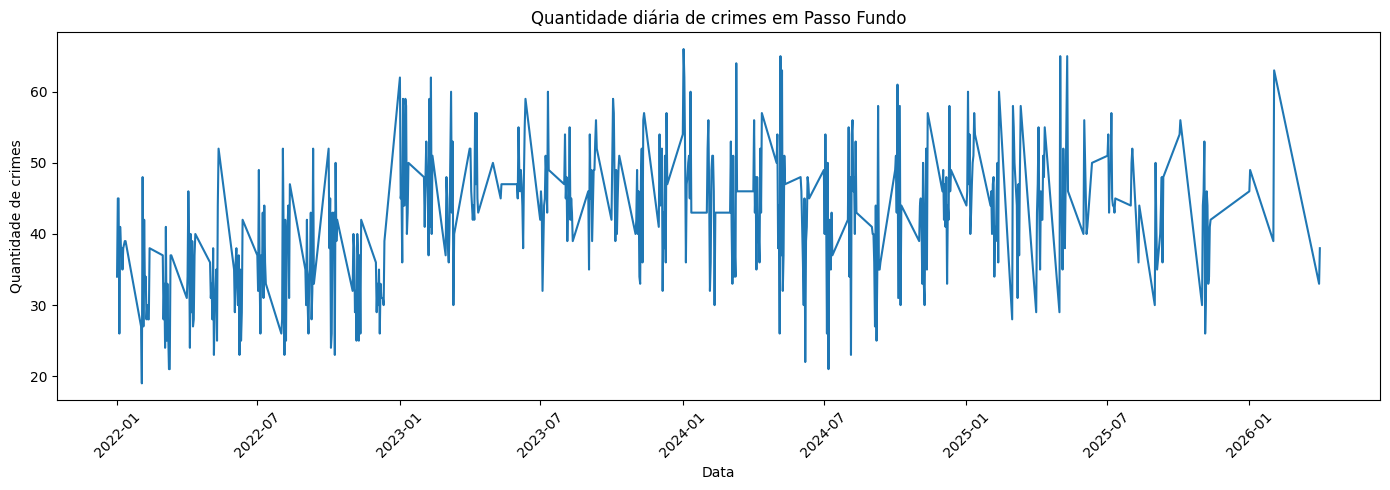

In [36]:
# Gera a série temporal da quantidade diária de crimes para visualizar a evolução das ocorrências ao longo do período analisado.
# Cria a figura da série temporal de crimes por dia.
plt.figure(figsize=(14, 5))

# Plota a evolução diária da quantidade de crimes.
plt.plot(df_analise["data"], df_analise["qtd_crimes"])

# Define o título e os rótulos dos eixos.
plt.title("Quantidade diária de crimes em Passo Fundo")
plt.xlabel("Data")
plt.ylabel("Quantidade de crimes")

# Ajusta a rotação das datas no eixo x para melhorar a leitura.
plt.xticks(rotation=45)

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()
plt.show()


A série temporal da quantidade diária de crimes revela oscilações ao longo do período analisado, com ocorrência de picos em datas específicas. Esse comportamento sugere a presença de variações pontuais na dinâmica das ocorrências, sem indicar, visualmente, uma tendência contínua de crescimento ou de queda em todo o intervalo observado.


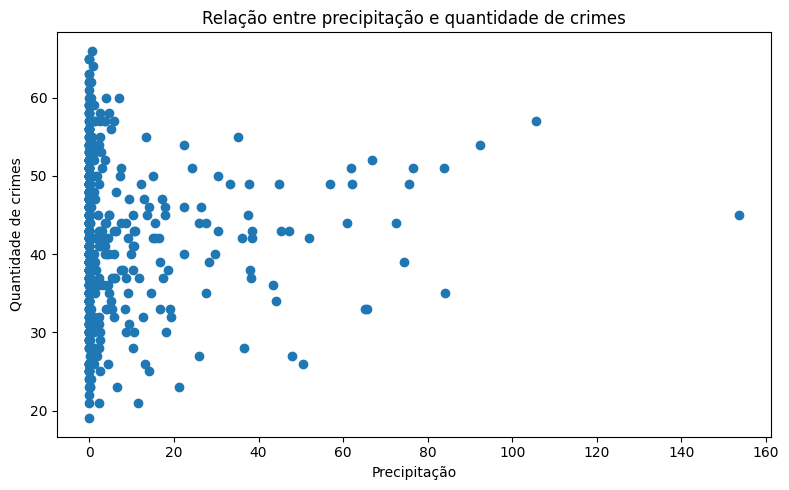

In [37]:
# Constrói o gráfico de dispersão entre precipitação e quantidade de crimes para observar possíveis associações entre chuva e ocorrências.
# Cria a figura do gráfico de dispersão entre precipitação e crimes.
plt.figure(figsize=(8, 5))

# Plota os pontos da relação entre precipitação e quantidade de crimes.
plt.scatter(df_analise["precipitacao"], df_analise["qtd_crimes"])

# Define o título e os rótulos dos eixos.
plt.title("Relação entre precipitação e quantidade de crimes")
plt.xlabel("Precipitação")
plt.ylabel("Quantidade de crimes")

# Ajusta o layout para evitar cortes na visualização.
plt.tight_layout()
plt.show()


O gráfico de dispersão entre precipitação e quantidade de crimes sugere uma associação negativa fraca. Em termos visuais, os maiores volumes de ocorrências tendem a aparecer com mais frequência em dias de pouca ou nenhuma chuva. Ainda assim, a dispersão dos pontos indica que essa relação não é suficiente, por si só, para explicar a variação da criminalidade.


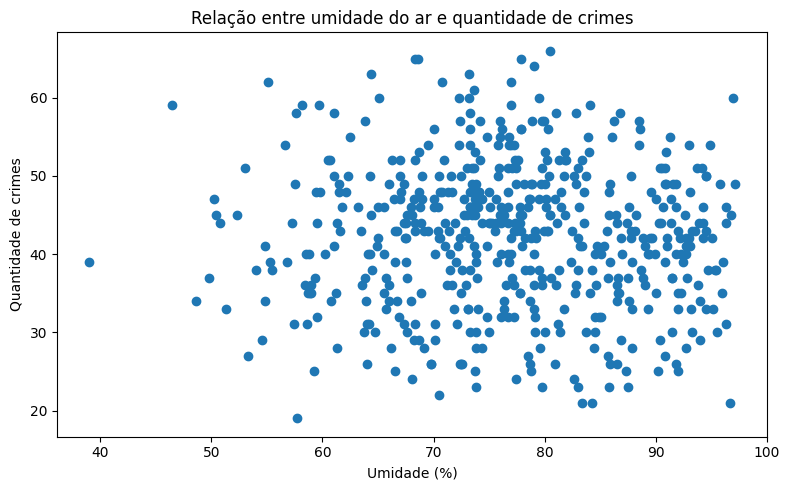

In [40]:
# Relação entre umidade e quantidade de crimes
plt.figure(figsize=(8, 5))

plt.scatter(df_analise["umidade"], df_analise["qtd_crimes"])

plt.title("Relação entre umidade do ar e quantidade de crimes")
plt.xlabel("Umidade (%)")
plt.ylabel("Quantidade de crimes")

plt.tight_layout()
plt.show()

A relação entre temperatura máxima e quantidade de crimes apresenta alta dispersão e não evidencia um padrão linear forte. Os registros criminais se distribuem por diferentes faixas de temperatura, o que indica que essa variável, isoladamente, não explica de forma consistente a oscilação diária das ocorrências.

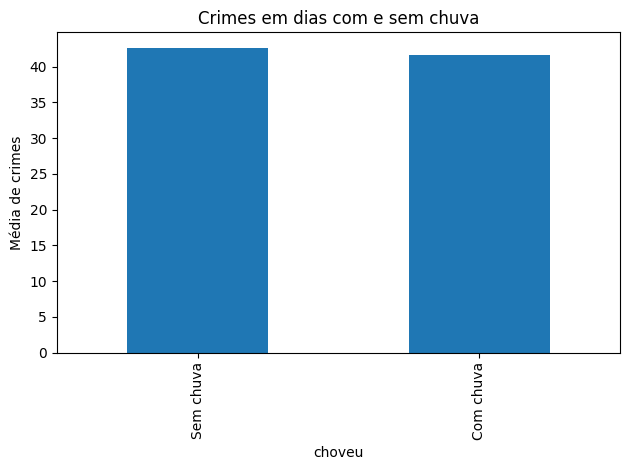

In [72]:
df_analise["choveu"] = df_analise["precipitacao"] > 0

df_chuva = (
    df_analise
    .groupby("choveu")["qtd_crimes"]
    .mean()
)

df_chuva.plot(kind="bar")

plt.title("Crimes em dias com e sem chuva")
plt.xticks([0,1], ["Sem chuva", "Com chuva"])
plt.ylabel("Média de crimes")

plt.tight_layout()
plt.show()

Os resultados indicam que variáveis climáticas, como precipitação e umidade, apresentam baixa correlação direta com a quantidade de crimes. No entanto, análises complementares, como a distribuição por dia da semana, sugerem que fatores comportamentais e sociais podem exercer maior influência na dinâmica da criminalidade.

# 6.1  — Correlação entre variáveis

Selecionamos variáveis climáticas com maior potencial explicativo sobre comportamento humano.

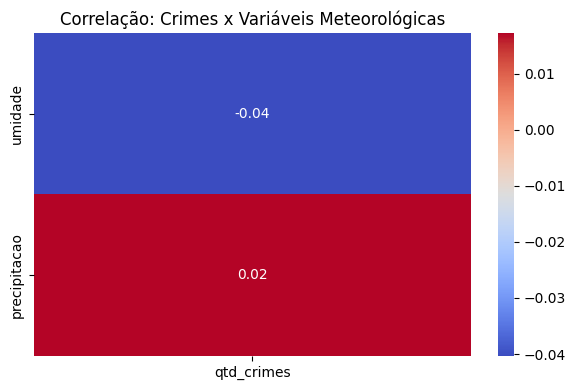

In [41]:
# Seleciona apenas as variáveis relevantes para o cálculo das correlações com a quantidade de crimes.
colunas_relevantes = [
    "qtd_crimes",
    "umidade",
    "precipitacao"
]

# Cria um recorte da base final contendo somente as variáveis escolhidas.
df_corr = df_final[colunas_relevantes]

# Calcula a matriz de correlação entre as variáveis selecionadas.
correlacoes = df_corr.corr()

# Mantém somente a coluna de correlação com a variável quantidade de crimes.
cor_crimes = correlacoes[["qtd_crimes"]].drop("qtd_crimes")

# Cria a figura do mapa de calor das correlações.
plt.figure(figsize=(6, 4))

# Exibe o heatmap apenas das correlações entre crimes e variáveis meteorológicas.
sns.heatmap(cor_crimes, annot=True, cmap="coolwarm", fmt=".2f")

# Define o título e ajusta o layout final do gráfico.
plt.title("Correlação: Crimes x Variáveis Meteorológicas")
plt.tight_layout()


A matriz de correlação indica que a quantidade de crimes possui correlação linear fraca com as variáveis meteorológicas analisadas. Em contrapartida, algumas relações esperadas entre variáveis climáticas aparecem com maior intensidade, como a associação entre precipitação e umidade e a relação positiva entre temperatura máxima e temperatura mínima.

De modo geral, os resultados sugerem que o comportamento da criminalidade não depende apenas do clima, sendo necessário considerar outros fatores para uma interpretação mais ampla do fenômeno.


## Etapa 7 — Exportação dos resultados

Ao final do processo, as principais bases podem ser exportadas para arquivo. Essa etapa facilita a entrega do dataset tratado e preserva, separadamente, a base integrada, a base analítica e a versão normalizada.


In [75]:
# Exporta as principais bases tratadas para arquivos CSV na pasta do projeto.
# Define o caminho de saída da base integrada final.
caminho_saida_final = os.path.join(pasta_base, 'base_integrada_final.csv')

# Define o caminho de saída da base analítica diária.
caminho_saida_analise = os.path.join(pasta_base, 'base_analitica_diaria.csv')

# Define o caminho de saída da base normalizada para modelo.
caminho_saida_modelo = os.path.join(pasta_base, 'base_normalizada_modelo.csv')

# Exporta a base integrada final em formato CSV.
df_final.to_csv(caminho_saida_final, index=False, encoding='utf-8-sig')

# Exporta a base analítica diária em formato CSV.
df_analise.to_csv(caminho_saida_analise, index=False, encoding='utf-8-sig')

# Exporta a base normalizada em formato CSV.
df_modelo.to_csv(caminho_saida_modelo, index=False, encoding='utf-8-sig')

# Informa no console quais arquivos foram gerados.
print('Arquivo exportado:', caminho_saida_final)
print('Arquivo exportado:', caminho_saida_analise)
print('Arquivo exportado:', caminho_saida_modelo)


Arquivo exportado: /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/base_integrada_final.csv
Arquivo exportado: /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/base_analitica_diaria.csv
Arquivo exportado: /content/drive/MyDrive/TRABALHO_MACHINE_LEARNING/base_normalizada_modelo.csv


- A base normalizada corresponde ao conjunto de dados de criminalidade após passar por etapas de limpeza e padronização, garantindo consistência, correção de tipos (como datas) e remoção de inconsistências.
- A base analítica diária, por sua vez, representa a agregação desses dados ao nível temporal, onde cada registro corresponde a um dia, permitindo a análise da quantidade de crimes ao longo do tempo.
- Base integrada final resulta da junção entre os dados de criminalidade e as informações meteorológicas, reunindo em um único arquivo todas as variáveis necessárias para análises mais avançadas, como correlações, visualizações e geração de insights.